# Programming Sheet 1

In [6]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.interpolate import interp1d

## Exercise 1.2

### a) stockprice

In [3]:
def stockprice(P0, u, d):
    return np.array([[P0, 0], [P0*u, P0*d]])

In [4]:
P = stockprice(4, 1.1, 0.9)
print(P)

[[4.  0. ]
 [4.4 3.6]]


### b) callpayoff

In [5]:
def callpayoff(P, K):
    return np.maximum(P[-1,:] - K, 0)

In [6]:
print(callpayoff(P, 4))

[0.4 0. ]


### c) market volatility

In [8]:
def u(r, sigma):
    num = 1 + (1 + r)**2 * np.exp(sigma**2) + np.sqrt((1 + (1 + r)**2 * np.exp(sigma**2))**2 - 4 * (1 + r)**2)
    den = 2 * (1 + r)
    return num / den

In [9]:
r = 0.01
sigma = 0.2
u = u(r, sigma)
d = 1/u

print('u: ', u)
print('d: ', d)

u:  1.2249741041456468
d:  0.8163437876896557


### d) Example

In [10]:
P0 = 100
K = 80

In [11]:
P = stockprice(P0, u, d)
print(P)

[[100.           0.        ]
 [122.49741041  81.63437877]]


In [12]:
Payoff = callpayoff(P, K)
print(Payoff)

[42.49741041  1.63437877]


### e) callprice

In [21]:
def qt(r, u, d):
    return (1 + r - d) / (u - d)

def callprice(P0, u, d, r, K):
    P = stockprice(P0, u, d)
    Payoff = callpayoff(P, K)
    q = qt(r, u, d)
    return 1 / (1 + r) * (q * Payoff[0] + (1 - q) * Payoff[1])

In [22]:
q = qt(r, u, d)
price = callprice(P0, u, d, r, K)
print('q: ', q)
print('Call price: ', price)

q:  0.4739154304308717
Call price:  20.792079207920793


### f) price

In [23]:
def price(P0, u, d, r, payoff_fct, **kwargs):
    P1 = stockprice(P0, u, d)[-1,:]
    q = qt(r, u, d)
    payoff = payoff_fct(P1, **kwargs)
    return 1 / (1 + r) * (q * payoff[0] + (1 - q) * payoff[1])

### g) digital payoff and power call payoff

In [24]:
def digitalpayoff(P1, K):
    return np.array([int(P1[0] > K), int(P1[1] > K)])

def powercallpayoff(P1, K, alpha):
    return np.maximum(P1 - K, 0)**alpha

In [25]:
print(price(P0, u, d, r, digitalpayoff, K=80))
print(price(P0, u, d, r, powercallpayoff, K=80, alpha=0.5))
print(price(P0, u, d, r, powercallpayoff, K=80, alpha=1))
print(price(P0, u, d, r, powercallpayoff, K=80, alpha=2))

0.9900990099009901
3.7247701567861804
20.792079207920793
848.82248270946


## Exercise 1.3

### a) Download dataset

In [9]:
import yfinance as yf
print(yf.__version__)

0.2.66


In [10]:
dax = yf.download('^GDAXI', start='2010-01-01', end='2024-10-31')
dax = dax['Close']
print(dax.head())
print(dax.tail())

C:\Users\ga58rus\AppData\Local\Temp\ipykernel_23352\3621447976.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dax = yf.download('^GDAXI', start='2010-01-01', end='2024-10-31')
[*********************100%***********************]  1 of 1 completed

Ticker           ^GDAXI
Date                   
2010-01-04  6048.299805
2010-01-05  6031.859863
2010-01-06  6034.330078
2010-01-07  6019.359863
2010-01-08  6037.609863
Ticker            ^GDAXI
Date                    
2024-10-24  19443.000000
2024-10-25  19463.589844
2024-10-28  19531.619141
2024-10-29  19478.070312
2024-10-30  19257.339844


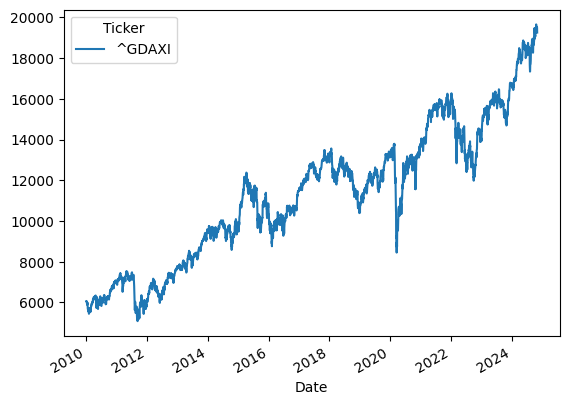

In [11]:
dax.plot()
plt.show()

### b) log-returns and simple returns

In [33]:
logret = np.log(dax / dax.shift(1))
logret = logret.dropna()
print(logret.head())
print(logret.tail())

Date
2010-01-05   -0.002722
2010-01-06    0.000409
2010-01-07   -0.002484
2010-01-08    0.003027
2010-01-11    0.000479
Name: Adj Close, dtype: float64
Date
2024-10-24    0.003368
2024-10-25    0.001058
2024-10-28    0.003489
2024-10-29   -0.002745
2024-10-30   -0.011397
Name: Adj Close, dtype: float64


In [35]:
simpleret = (dax - dax.shift(1)) / dax.shift(1)
simpleret = simpleret.dropna()
print(simpleret.head())
print(simpleret.tail())

Date
2010-01-05   -0.002718
2010-01-06    0.000410
2010-01-07   -0.002481
2010-01-08    0.003032
2010-01-11    0.000479
Name: Adj Close, dtype: float64
Date
2024-10-24    0.003374
2024-10-25    0.001059
2024-10-28    0.003495
2024-10-29   -0.002742
2024-10-30   -0.011332
Name: Adj Close, dtype: float64


### c) annualized mean and std

In [36]:
mean = np.mean(logret) * 252
std = np.std(logret) * np.sqrt(252)
print('Annualized mean: ', mean)
print('Annualized standard deviation: ', std)

Annualized mean:  0.07751527162528883
Annualized standard deviation:  0.19598739409269256


### d) non-normality

In [38]:
skewness = stats.skew(logret)
kurtosis = stats.kurtosis(logret)
print('Skewness: ', skewness)
print('Kurtosis: ', kurtosis)
print('Normal Skewness: ', 0)
print('Normal Kurtosis: ', 3)

Skewness:  -0.48159246712604953
Kurtosis:  7.714545231018056
Normal Skewness:  0
Normal Kurtosis:  3


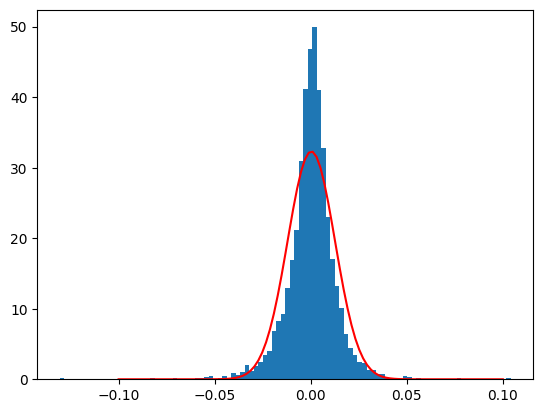

In [ ]:
plt.hist(logret, bins=100, density=True)
x = np.linspace(-0.1, 0.1, 100)
pdf = stats.norm.pdf(x, mean / 252, std / np.sqrt(252))
plt.plot(x, pdf, color='r')
plt.show()

## Exercise 1.4

### a) continuous rates

In [67]:
def continuousrate(B, T):
    return - np.log(B) / T

def lineardiscountfactor(r, T):
    return 1 / (1 + r * T)

In [68]:
T = np.array([0.5, 1, 2, 3, 4])
B = np.array([lineardiscountfactor(0.043, 0.5), 0.956, 0.9117, 0.8685, 0.825])

print(B)

[0.97895252 0.956      0.9117     0.8685     0.825     ]


In [69]:
R = continuousrate(B, T)
print(R)

[0.04254427 0.04499737 0.04622215 0.0469959  0.04809297]


### b) interpolation

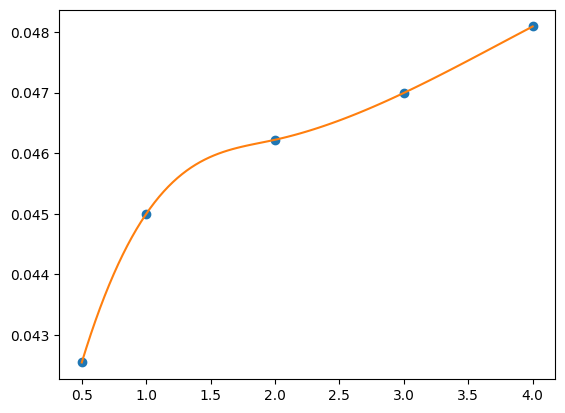

In [70]:
f = interp1d(T, R, kind='cubic')
T_new = np.linspace(0.5, 4, 100)
R_new = f(T_new)

plt.plot(T, R, 'o', T_new, R_new, '-')
plt.show()

### c) coupon bond price

In [ ]:
payoffs = np.array([5, 5, 5, 5, 5, 5, 5, 105])
Times = np.array([0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4])
rates = f(Times)
discounts = np.exp(-rates * Times)
print(discounts)

price = np.sum(payoffs * discounts)
print(price)

[0.97895252 0.956      0.93341033 0.9117     0.89015969 0.8685
 0.84674302 0.825     ]
118.55232781019488


## Exercise 1.5

In [51]:
def butterflyspread(P, K1, K2, K3):
    return np.maximum(P - K1, 0) - 2 * np.maximum(P - K2, 0) + np.maximum(P - K3, 0)

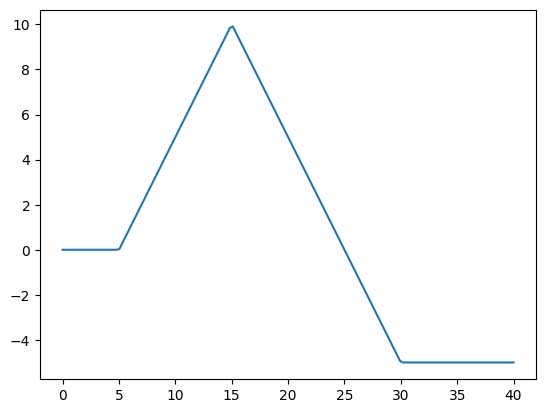

In [54]:
# plot the butterfly spread for different strikes
P = np.linspace(0, 40, 160)
plt.plot(P, butterflyspread(P, 5, 15, 30))
plt.show()